## **AnalisIs EDA**

In [2]:
import pandas as pd

df = pd.read_csv("C:/Users/juanc/.cache/kagglehub/competitions/ieee-fraud-detection/train_transaction.csv")

df.shape

(590540, 394)

In [51]:
df.columns

Index(['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt',
       'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5',
       ...
       'V330', 'V331', 'V332', 'V333', 'V334', 'V335', 'V336', 'V337', 'V338',
       'V339'],
      dtype='str', length=394)

In [3]:
df.isnull().sum()

TransactionID          0
isFraud                0
TransactionDT          0
TransactionAmt         0
ProductCD              0
                   ...  
V335              508189
V336              508189
V337              508189
V338              508189
V339              508189
Length: 394, dtype: int64

In [4]:
df.describe()

,TransactionID,isFraud,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
count,5.905400e+05,590540.000000,5.905400e+05,590540.000000,590540.000000,581607.000000,588975.000000,586281.000000,524834.000000,524834.000000,...,82351.000000,82351.000000,82351.000000,82351.000000,82351.000000,82351.00000,82351.000000,82351.000000,82351.000000,82351.000000
mean,3.282270e+06,0.034990,7.372311e+06,135.027176,9898.734658,362.555488,153.194925,199.278897,290.733794,86.800630,...,0.775874,721.741883,1375.783644,1014.622782,9.807015,59.16455,28.530903,55.352422,151.160542,100.700882
std,1.704744e+05,0.183755,4.617224e+06,239.162522,4901.170153,157.793246,11.336444,41.244453,101.741072,2.690623,...,4.727971,6217.223583,11169.275702,7955.735482,243.861391,387.62948,274.576920,668.486833,1095.034387,814.946722
min,2.987000e+06,0.000000,8.640000e+04,0.251000,1000.000000,100.000000,100.000000,100.000000,100.000000,10.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,3.134635e+06,0.000000,3.027058e+06,43.321000,6019.000000,214.000000,150.000000,166.000000,204.000000,87.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
50%,3.282270e+06,0.000000,7.306528e+06,68.769000,9678.000000,361.000000,150.000000,226.000000,299.000000,87.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
75%,3.429904e+06,0.000000,1.124662e+07,125.000000,14184.000000,512.000000,150.000000,226.000000,330.000000,87.000000,...,0.000000,0.000000,25.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
max,3.577539e+06,1.000000,1.581113e+07,31937.391000,18396.000000,600.000000,231.000000,237.000000,540.000000,102.000000,...,55.000000,160000.000000,160000.000000,160000.000000,55125.000000,55125.00000,55125.000000,104060.000000,104060.000000,104060.000000


In [11]:
df.groupby("isFraud")['TransactionAmt'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,569877.0,134.511665,239.395078,0.251,43.970,68.5,120.0,31937.391
1,20663.0,149.244779,232.212163,0.292,35.044,75.0,161.0,5191.000


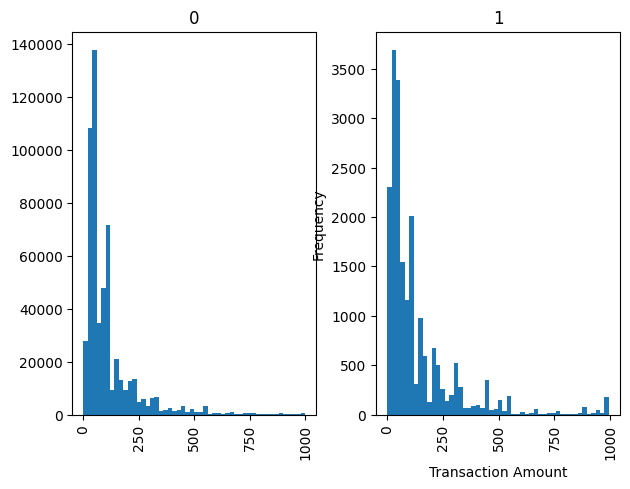

In [18]:
import matplotlib.pyplot as plt

df[df['TransactionAmt'] < 1000].hist(column='TransactionAmt', by='isFraud', bins=50)
plt.tight_layout()
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.show()

In [67]:
suma_isFraud = df.groupby('isFraud')['TransactionAmt'].mean()

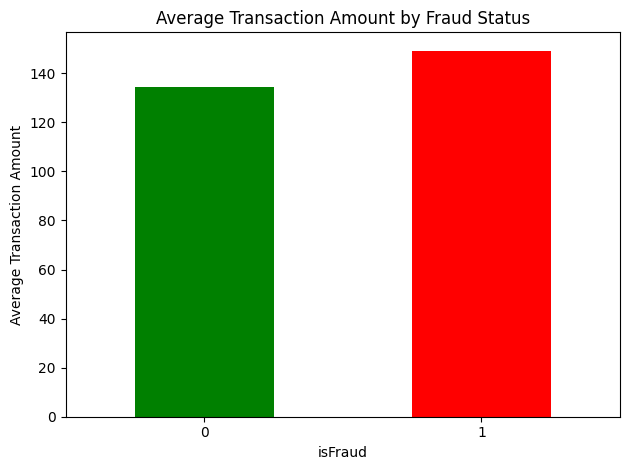

In [70]:
suma_isFraud.plot(kind='bar')
ax = suma_isFraud.plot(kind='bar', color=['green', 'red'])
plt.xlabel('isFraud')
plt.ylabel('Average Transaction Amount')
plt.title('Average Transaction Amount by Fraud Status')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

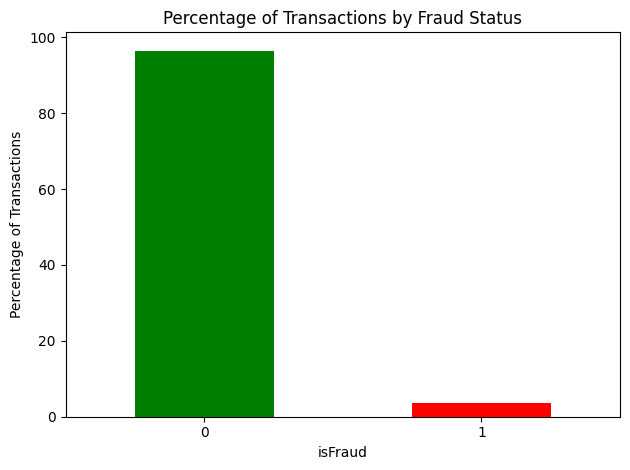

In [72]:
suma_isFraud_count =  df['isFraud'].value_counts(normalize=True) * 100
suma_isFraud_count.plot(kind='bar')
ax = suma_isFraud_count.plot(kind='bar', color=['green', 'red'])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xlabel('isFraud')
plt.ylabel('Percentage of Transactions')
plt.title('Percentage of Transactions by Fraud Status')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [53]:
df_train_identity = pd.read_csv("data/train_identity.csv")

In [54]:
df_complete = df.merge(df_train_identity, on='TransactionID', how='left')

In [56]:
print(df_complete.shape)
df_complete.head()

(590540, 434)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [58]:
df_complete.DeviceType.value_counts().isnull().sum()

np.int64(0)

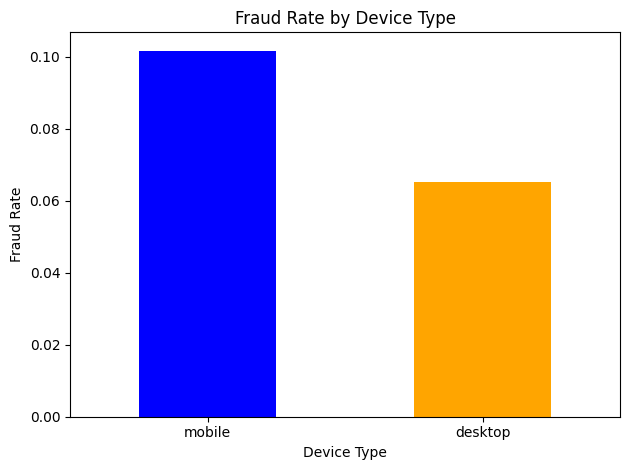

In [66]:
suma_device = df_complete.groupby('DeviceType')['isFraud'].mean().sort_values(ascending=False)
suma_device.plot(kind='bar')
ax = suma_device.plot(kind='bar', color=['blue', 'orange'])
plt.xlabel('Device Type')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Device Type')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

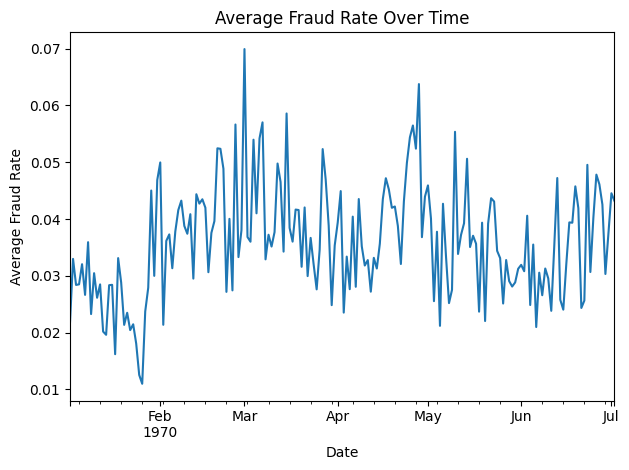

In [74]:
# Distribución temporal — ¿el fraude varía con el tiempo?
import matplotlib.pyplot as plt

df['TransactionDT'] = pd.to_datetime(df['TransactionDT'], unit='s')
df.set_index('TransactionDT', inplace=True)
df['isFraud'].resample('D').mean().plot()
plt.xlabel('Date')
plt.ylabel('Average Fraud Rate')
plt.title('Average Fraud Rate Over Time')
plt.tight_layout()
plt.show()

In [85]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


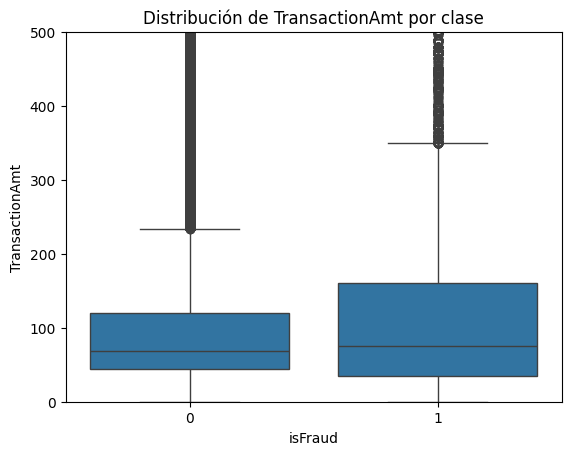

In [86]:
import seaborn as sns

sns.boxplot(data=df, x='isFraud', y='TransactionAmt')
plt.ylim(0, 500)  # limita el eje para que se vea bien — hay outliers enormes
plt.title('Distribución de TransactionAmt por clase')
plt.show()